In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib as jb
import streamlit as st

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("C:\\Users\\USER-11\\Downloads\\loan_default_dataset (1).csv")

In [26]:
df.shape

(200, 12)

In [27]:
df.dtypes

age                        int64
income                     int64
loan_amount                int64
loan_term_months           int64
credit_score               int64
employment_years           int64
debt_to_income_ratio     float64
num_credit_lines           int64
past_delinquencies         int64
loan_default               int64
credit_score_range      category
dti_rounded              float64
dtype: object

In [3]:
df.head()

,age,income,loan_amount,loan_term_months,credit_score,employment_years,debt_to_income_ratio,num_credit_lines,past_delinquencies,loan_default
0,59,69811,5142,36,807,0,0.45,6,3,1
1,49,22811,16202,36,368,3,0.30,8,4,0
2,35,76250,40734,24,845,1,0.21,5,4,0
3,28,92082,8079,48,352,9,0.42,2,4,0
4,41,54754,8987,12,749,4,0.31,6,2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   200 non-null    int64  
 1   income                200 non-null    int64  
 2   loan_amount           200 non-null    int64  
 3   loan_term_months      200 non-null    int64  
 4   credit_score          200 non-null    int64  
 5   employment_years      200 non-null    int64  
 6   debt_to_income_ratio  200 non-null    float64
 7   num_credit_lines      200 non-null    int64  
 8   past_delinquencies    200 non-null    int64  
 9   loan_default          200 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 15.8 KB


In [5]:
df.isnull().sum()

age                     0
income                  0
loan_amount             0
loan_term_months        0
credit_score            0
employment_years        0
debt_to_income_ratio    0
num_credit_lines        0
past_delinquencies      0
loan_default            0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

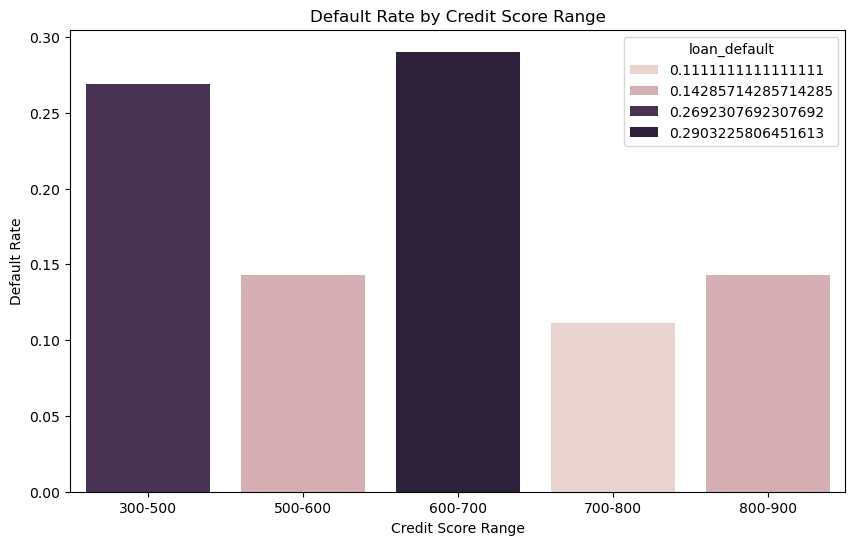

In [7]:
bins = [300, 500, 600, 700, 800, 900]
labels = ['300-500', '500-600', '600-700', '700-800', '800-900']
df['credit_score_range'] = pd.cut(df['credit_score'], bins=bins, labels=labels)
default_rate_cs = df.groupby('credit_score_range', observed=False)['loan_default'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=default_rate_cs, x='credit_score_range',y ='loan_default',  hue='loan_default')
plt.title('Default Rate by Credit Score Range')
plt.ylabel('Default Rate')
plt.xlabel('Credit Score Range')
plt.savefig('bar_plot_credit_score.png')
plt.show()

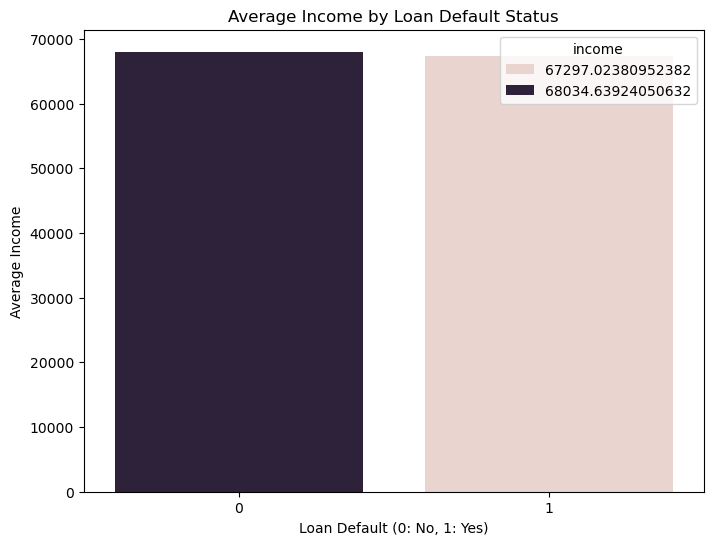

In [8]:
avg_income_default = df.groupby('loan_default')['income'].mean().reset_index()
plt.figure(figsize=(8, 6))
sns.barplot(data=avg_income_default, x='loan_default', y='income',hue='income')
plt.title('Average Income by Loan Default Status')
plt.ylabel('Average Income')
plt.xlabel('Loan Default (0: No, 1: Yes)')
plt.savefig('bar_plot_avg_income.png')
plt.show()

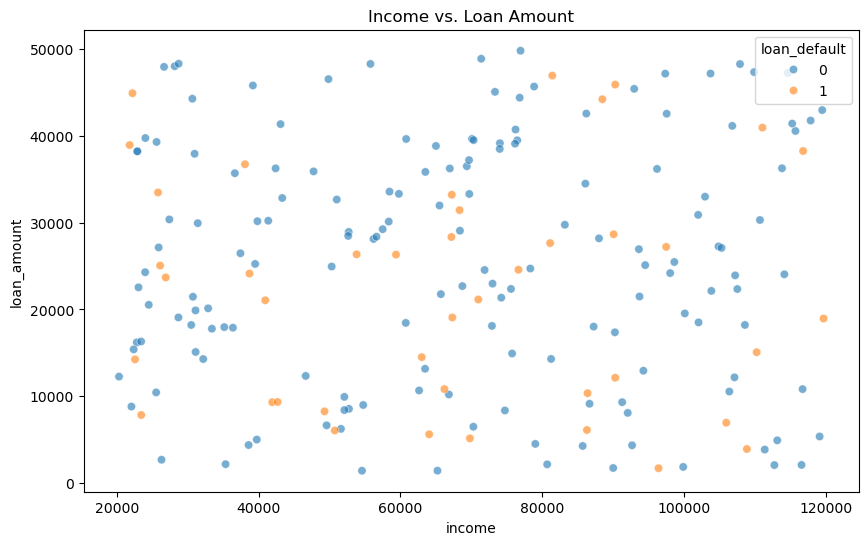

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='income', y='loan_amount', hue='loan_default', alpha=0.6)
plt.title('Income vs. Loan Amount')
plt.savefig('scatter_plot_income_loan.png')
plt.show()

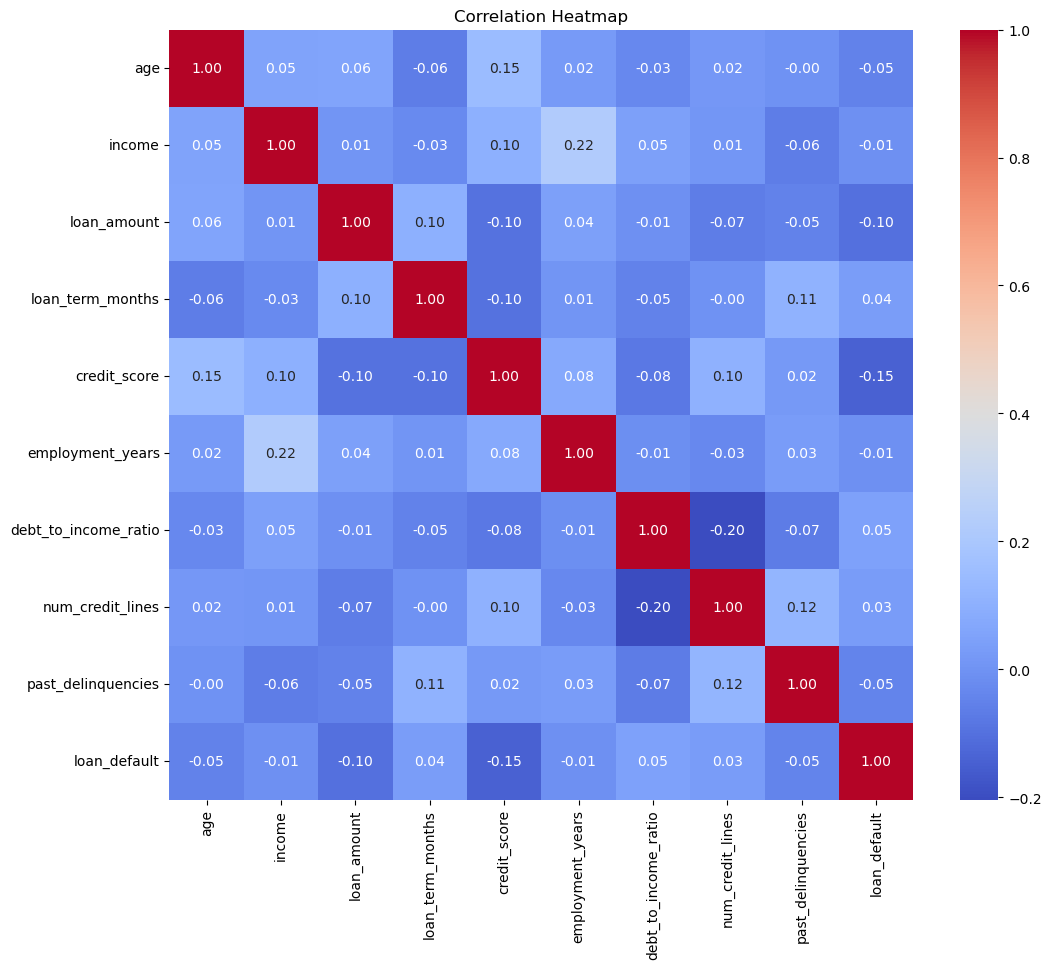

In [10]:
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('heatmap_correlation.png')
plt.show()

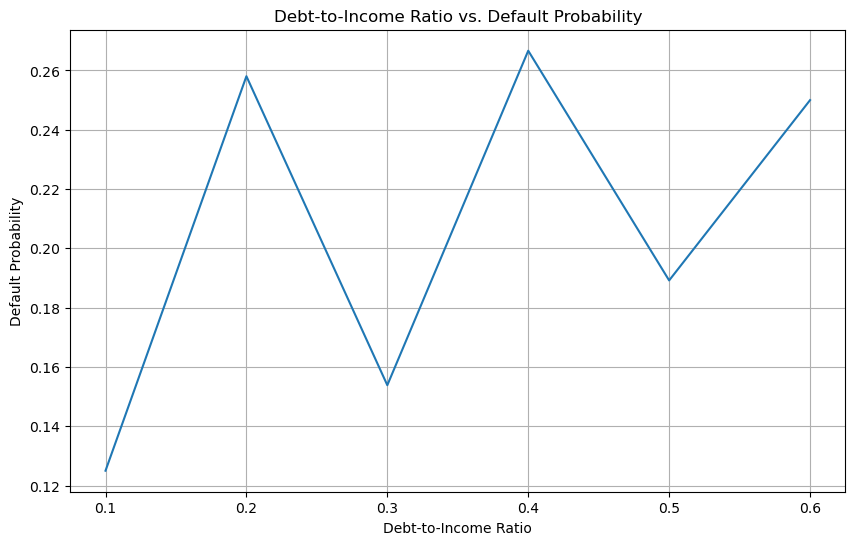

In [11]:
df['dti_rounded'] = df['debt_to_income_ratio'].round(1)
dti_trend = df.groupby('dti_rounded')['loan_default'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=dti_trend, x='dti_rounded', y='loan_default')
plt.title('Debt-to-Income Ratio vs. Default Probability')
plt.ylabel('Default Probability')
plt.xlabel('Debt-to-Income Ratio')
plt.grid(True)
plt.savefig('line_plot_dti.png')
plt.show()

In [12]:
x = df.drop(['loan_default'],axis = 1)
y = df['loan_default']

In [13]:
numerical_cols = x.select_dtypes(include=['int64','float64']).columns.tolist()

In [14]:
categorical_cols = x.select_dtypes(include=['object']).columns.tolist()


In [15]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [16]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [17]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])


In [18]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [19]:
model = Pipeline(steps=[
    ('pre',preprocessor),('reg',RandomForestClassifier(n_estimators=200,random_state=42))
])

In [20]:
model.fit(X_train,y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'income',
                                                   'loan_amount',
                                                   'loan_term_months',
                                                   'credit_score',
                                                   'employment_years',
                                                   'debt_to_income_ratio',
                                                   'num_credit_lines',
                                                   'past_delinquencies',
                                                   'dti_rounded']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('reg',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [21]:
y_pred = model.predict(X_test)
print(f'accuracy:{accuracy_score(y_pred,y_test)*100:2f}')
print(f'{classification_report(y_pred,y_test,zero_division=0)}')

accuracy:85.000000
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        40
           1       0.00      0.00      0.00         0

    accuracy                           0.85        40
   macro avg       0.50      0.42      0.46        40
weighted avg       1.00      0.85      0.92        40



In [92]:
jb.dump(model,'RandomForestClassifier.pkl')

['RandomForestClassifier.pkl']

In [93]:
load = jb.load('RandomForestClassifier.pkl')

st.set_page_config(
    page_title="Loan Default Prediction",
    page_icon="💰",
    layout="wide"
)

st.title("💰 Loan Default Prediction App")

st.write(
    """
    This app predicts whether a customer is likely to **default on a loan** using a trained Machine Learning model.
    Fill in the customer information and click **Predict**.
    """
)

col1, col2 = st.columns(2)

with col1:
    age = st.number_input('Age')
    income = st.number_input('Income')
    loan_amount = st.number_input('Loan Amount')
    credit_score = st.number_input('Credit Score')
    employment_years = st.number_input('Employment Years')

with col2:
    loan_term_months = st.number_input('Loan Term (Months)')
    debt_to_income_ratio = st.number_input('Debt to Income Ratio')
    num_credit_lines = st.number_input('Number of Credit Lines')
    past_delinquencies = st.number_input('Past Delinquencies')
    dti_rounded = st.number_input('DTI Rounded')
    
credit_score_range = st.selectbox(
    "Credit_Score_Range",
    ['300-500','500-600','600-700','700-800','800-900']
)

st.markdown("---")

if st.button("🔍 Predict Loan Status"):
    data = pd.DataFrame({   
        'age':[age],
        'income':[income],
        'loan_amount':[loan_amount],
        'loan_term_months':[loan_term_months],
        'credit_score':[credit_score],
        'employment_years':[employment_years],
        'debt_to_income_ratio':[debt_to_income_ratio],
        'num_credit_lines':[num_credit_lines],
        'past_delinquencies':[past_delinquencies],
        'credit_score_range':[credit_score_range],
        'dti_rounded':[dti_rounded]
    })


    prediction = model.predict(data)

    if prediction[0] == 1:
        st.error("⚠️ High Risk: Customer may Default")
    else:
        st.success("✅ Low Risk: Customer likely to Repay Loan")


st.sidebar.write("""
Model: Random Forest  
Type: Classification  
Use Case: Loan Risk Prediction
""")

st.markdown("---")
st.write("Developed by Nahidul Islam | Data Science & ML")

2026-03-10 15:30:25.417 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 15:30:25.418 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 15:30:25.419 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 15:30:25.420 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 15:30:25.420 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 15:30:25.421 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 15:30:25.421 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-10 15:30:25.422 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar